In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

**Feature Selection**

https://scikit-learn.org/stable/modules/feature_selection.html

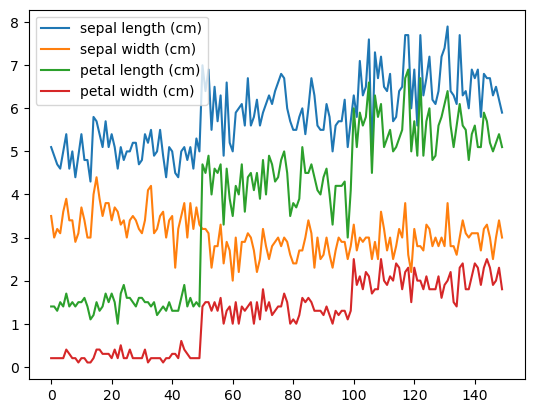

In [2]:
#Variance de données

#Supprimer les attributs ayany une variance petite
#L'attribut avec variance 0: qq soit la donnée la même valeur

from sklearn.feature_selection import VarianceThreshold
     

from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

axe=np.arange(0,150)
plt.plot(axe,X[:,0])
plt.plot(axe,X[:,1])
plt.plot(axe,X[:,2])
plt.plot(axe,X[:,3])
plt.legend(iris.feature_names)
     



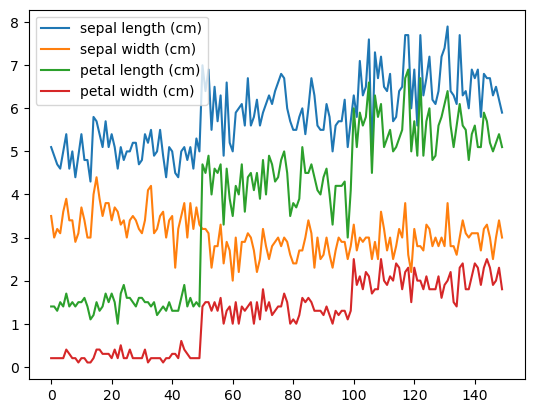

In [3]:
plt.plot(X)
plt.legend(iris.feature_names)

In [4]:
X.var(axis=0)

array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

Petal length  a la variance plus grande; sepal width a la variance plus petite

In [5]:
selector = VarianceThreshold(threshold=0.2)
selector.fit(X)

VarianceThreshold(threshold=0.2)

In [6]:
selector.get_support()

array([ True, False,  True,  True])

In [7]:
np.array(iris.feature_names)[selector.get_support()]

array(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'],
      dtype='<U17')

**Test de dependance**

#SelectKBest(test_dependance, K)

https://scikit-learn.org/stable/auto_examples/feature_selection/plot_feature_selection.html

On choisit les plus importants attributs dont l'étiquette depend le plus  (en se basant sur les tests statistiques comme chi-squared, Analysis of Variance (ANOVA), etc. ). 

In [8]:
from sklearn.feature_selection import SelectKBest,chi2, f_classif

In [9]:
selector = SelectKBest( k=2)
#f_classif par defaut
selector.fit(X, y)
selector.scores_
     

array([ 119.26450218,   49.16004009, 1180.16118225,  960.0071468 ])

In [10]:
np.array(iris.feature_names)[selector.get_support()]

array(['petal length (cm)', 'petal width (cm)'], dtype='<U17')

In [11]:
selector2 = SelectKBest(chi2, k=2)
selector2.fit(X, y)
selector2.scores_

array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ])

In [12]:
np.array(iris.feature_names)[selector2.get_support()]

array(['petal length (cm)', 'petal width (cm)'], dtype='<U17')

**Choisir en fonction de la méthode choisie (Modèles avec paramètres)**

In [13]:
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import SGDClassifier

In [14]:
selector = SelectFromModel(SGDClassifier(random_state=0), threshold='mean')
selector.fit_transform(X, y)

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [15]:
np.array(iris.feature_names)[selector.get_support()]

array(['petal length (cm)', 'petal width (cm)'], dtype='<U17')

**Matrice de corrélation**

In [16]:
dataf=pd.DataFrame(X)

In [17]:
display(dataf)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [18]:
dataf['target']=y

In [19]:
display(dataf)

,0,1,2,3,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [20]:
correlation_matrice=dataf.corr()

<Axes: >

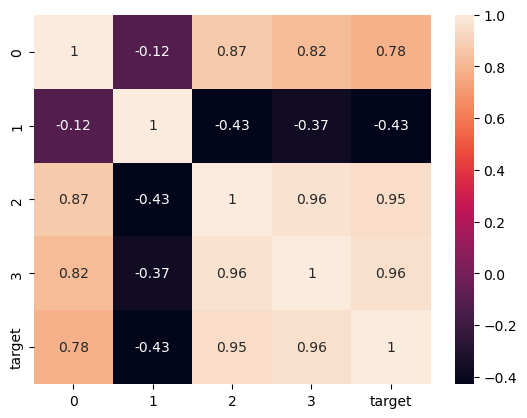

In [21]:
sns.heatmap(correlation_matrice, annot=True)